In [1]:
import pandas as pd
import numpy as np


In [2]:
pip install openpyxl


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd

file_path = "/Users/sworajkhadka/Documents/Customer-Segmentation/online_retail_II.xlsx"

df1 = pd.read_excel(file_path, sheet_name=0)
df2 = pd.read_excel(file_path, sheet_name=1)

df = pd.concat([df1, df2], ignore_index=True)

df.shape

(1067371, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [5]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [6]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


In [27]:
#Removing Cancellations 
#they mean not real purchases and exclude them from revenue & behaviour

In [28]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [29]:
#Removing returns as they dont contribute to the revenues as well
df = df[df['Quantity'] > 0]

In [30]:
#Removing missing customers , since alot of data is missing 
df = df.dropna(subset=['Customer ID'])

In [31]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CustomerID
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,13085
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,13085
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,13085
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,13085
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,13085


In [32]:
#since the Customer Id is in float, lets convert it into the integer format
df['Customer ID'] = df['Customer ID'].astype(int)

In [33]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CustomerID
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,13085
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,13085
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,13085
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,13085
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,13085


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  int64         
 7   Country      805620 non-null  object        
 8   CustomerID   805620 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 61.5+ MB


In [35]:
df = df.drop(columns=['CustomerID'])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   Customer ID  805620 non-null  int64         
 7   Country      805620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 55.3+ MB


In [37]:
df = df.rename(columns={'Customer ID': 'CustomerID'})

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      805620 non-null  object        
 1   StockCode    805620 non-null  object        
 2   Description  805620 non-null  object        
 3   Quantity     805620 non-null  int64         
 4   InvoiceDate  805620 non-null  datetime64[ns]
 5   Price        805620 non-null  float64       
 6   CustomerID   805620 non-null  int64         
 7   Country      805620 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 55.3+ MB


In [40]:
#now we create Transaction Value
df['Revenue'] = df['Quantity'] * df['Price']

In [41]:
#Convert Date Type
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [43]:
#verifying my clena data now
df.shape


(805620, 9)

In [44]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


# Creating Customer Aggregation Table

In [45]:
#Here we transform transctions-> Customers
#most imp DS transformation in customer ananlytics

In [46]:
#Reference Date(For Recency)
#Last purchase date+1 day


In [47]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

# Compute RFM

In [50]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [55]:
rfm.shape

(5881, 3)

In [52]:
df.shape

(805620, 9)

In [53]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [54]:
rfm.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888
std,209.474135,13.012879,14734.128619
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,347.800000
50%,96.000000,3.000000,897.620000
75%,380.000000,7.000000,2304.180000
max,739.000000,398.000000,608821.650000


# RSS Behavioral Features

In [57]:
orders = df.groupby(['CustomerID', 'Invoice']).agg({
    'InvoiceDate': 'max',
    'Revenue': 'sum',
    'Quantity': 'sum'
}).reset_index()

orders.head()

,CustomerID,Invoice,InvoiceDate,Revenue,Quantity
0,12346,491725,2009-12-14 08:34:00,45.0,10
1,12346,491742,2009-12-14 11:00:00,22.5,5
2,12346,491744,2009-12-14 11:02:00,22.5,5
3,12346,492718,2009-12-18 10:47:00,22.5,5
4,12346,492722,2009-12-18 10:55:00,1.0,1


In [59]:
#Customer Behavioral Aggregation

In [60]:
rss = orders.groupby('CustomerID').agg({
    'InvoiceDate': ['min', 'max', 'nunique'],
    'Revenue': ['sum', 'mean'],
    'Quantity': 'sum'
})

In [61]:
rss.columns = [
    'FirstPurchaseDate',
    'LastPurchaseDate',
    'TotalOrders',
    'TotalRevenue',
    'AvgOrderValue',
    'TotalItems'
]

rss.head()

,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AvgOrderValue,TotalItems
CustomerID,,,,,,
12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,77556.46,6463.038333,74285
12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,5633.32,704.165000,3286
12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2019.40,403.880000,2714
12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,4428.69,1107.172500,1624
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197


In [62]:
#Behavioral Features 
#Purchase Span-how long customer relationship lasted


In [63]:
rss['PurchaseSpanDays'] = (rss['LastPurchaseDate'] - rss['FirstPurchaseDate']).dt.days

In [65]:
#Purchase Interval - Avg days between orders
rss['PurchaseInterval'] = rss['PurchaseSpanDays'] / (rss['TotalOrders'] - 1)

In [66]:
rss['PurchaseInterval'] = rss['PurchaseInterval'].replace([np.inf, -np.inf], 0)
rss['PurchaseInterval'] = rss['PurchaseInterval'].fillna(0)

In [68]:
#Active Months

#How many months customer purchased in.

orders['YearMonth'] = orders['InvoiceDate'].dt.to_period('M')

active_months = orders.groupby('CustomerID')['YearMonth'].nunique()

rss['ActiveMonths'] = active_months

In [69]:
#Basket Size

#Items per order.
rss['AvgBasketSize'] = rss['TotalItems'] / rss['TotalOrders']

In [71]:
#Repeat Ratio
#orders per active month
rss['RepeatRatio'] = rss['TotalOrders'] / rss['ActiveMonths']

In [72]:
#NOW MERGE WITH FRM
#FRM+RSS
customer_features = rfm.merge(rss, on='CustomerID')
customer_features.head()

,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AvgOrderValue,TotalItems,PurchaseSpanDays,PurchaseInterval,ActiveMonths,AvgBasketSize,RepeatRatio
CustomerID,,,,,,,,,,,,,,
12346,326,12,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00,12,77556.46,6463.038333,74285,400,36.363636,5,6190.416667,2.4
12347,2,8,5633.32,2010-10-31 14:20:00,2011-12-07 15:52:00,8,5633.32,704.165000,3286,402,57.428571,8,410.750000,1.0
12348,75,5,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2019.40,403.880000,2714,362,90.500000,5,542.800000,1.0
12349,19,4,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00,4,4428.69,1107.172500,1624,570,190.000000,4,406.000000,1.0
12350,310,1,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.400000,197,0,0.000000,1,197.000000,1.0


In [73]:
customer_features.describe()

,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AvgOrderValue,TotalItems,PurchaseSpanDays,PurchaseInterval,ActiveMonths,AvgBasketSize,RepeatRatio
count,5881.000000,5881.000000,5881.000000,5881,5881,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,3017.076888,2010-08-22 07:16:55.174290176,2011-05-22 13:18:31.749702400,6.256249,3017.076888,391.518233,1822.975854,272.883183,74.039417,4.352661,253.703044,1.220715
min,1.000000,1.000000,0.000000,2009-12-01 07:45:00,2009-12-01 09:55:00,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,26.000000,1.000000,347.800000,2010-02-09 14:17:00,2010-11-25 10:11:00,1.000000,347.800000,181.390000,190.000000,0.000000,0.000000,1.000000,93.666667,1.000000
50%,96.000000,3.000000,897.620000,2010-06-27 13:29:00,2011-09-05 11:52:00,3.000000,897.620000,284.984000,491.000000,220.000000,45.800000,3.000000,158.000000,1.000000
75%,380.000000,7.000000,2304.180000,2011-01-30 14:36:00,2011-11-14 11:33:00,7.000000,2304.180000,420.500000,1376.000000,511.000000,101.000000,6.000000,262.391304,1.272727
max,739.000000,398.000000,608821.650000,2011-12-09 12:16:00,2011-12-09 12:50:00,396.000000,608821.650000,84236.250000,367833.000000,738.000000,714.000000,25.000000,87167.000000,18.875000
std,209.474135,13.012879,14734.128619,NaN,NaN,12.899816,14734.128619,1214.783901,8968.636988,258.815005,95.378753,4.493544,1433.498836,0.592551


# Phase 03- Customer Segmentation

In [74]:
seg_features = customer_features[[
    'Recency',
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'PurchaseSpanDays',
    'PurchaseInterval',
    'ActiveMonths',
    'AvgBasketSize',
    'RepeatRatio'
]]

In [76]:
#Now, we handle skew,Monetary & Frequency are highly skewed.
#so, we log-transform
import numpy as np

seg_features_log = np.log1p(seg_features)

In [77]:
#Scale features ,Clustering uses distance → scale required.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
seg_scaled = scaler.fit_transform(seg_features_log)


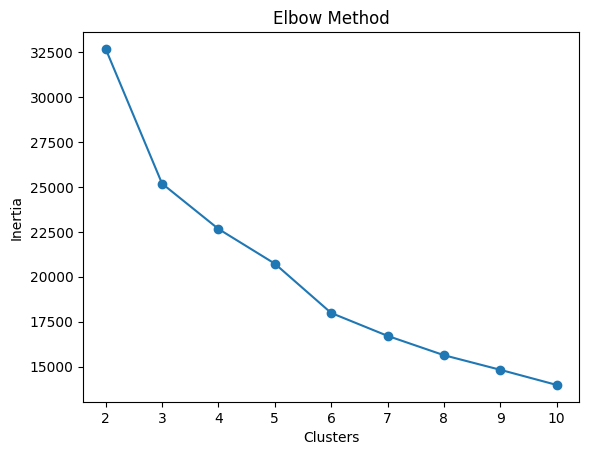

In [78]:
#IMP STEP' Find Optimal Cluster Count (ELBOW)'

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(seg_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [80]:
#Final CLustering 
#Assume k=4


kmeans = KMeans(n_clusters=4, random_state=42)
customer_features['Segment'] = kmeans.fit_predict(seg_scaled)

In [81]:
# Segment Profiles
#This is the business gold
segment_profile = customer_features.groupby('Segment').mean().round(2)
segment_profile

,Recency,Frequency,Monetary,FirstPurchaseDate,LastPurchaseDate,TotalOrders,TotalRevenue,AvgOrderValue,TotalItems,PurchaseSpanDays,PurchaseInterval,ActiveMonths,AvgBasketSize,RepeatRatio
Segment,,,,,,,,,,,,,,
0,202.66,3.77,686.39,2010-08-08 04:51:47.827225088,2011-05-21 07:51:33.612565504,3.76,686.39,188.76,362.12,285.62,130.14,3.25,100.69,1.18
1,357.14,1.07,346.61,2010-12-17 17:06:32.473867520,2010-12-17 20:19:39.512195072,1.07,346.61,322.83,201.47,0.12,0.11,1.01,192.20,1.06
2,37.76,20.56,11281.50,2010-04-03 00:32:51.335149824,2011-11-02 06:51:43.378746624,20.42,11281.50,464.68,6547.14,577.73,42.43,11.69,275.73,1.64
3,142.83,4.40,2403.16,2010-08-05 21:49:14.509804032,2011-07-20 04:55:05.372548864,4.39,2403.16,618.67,1707.37,347.78,123.97,3.94,459.88,1.14


In [82]:
segment_names = {
    0: "Occasional",
    1: "Churned",
    2: "VIP Loyal",
    3: "regular"
}

customer_features['SegmentName'] = customer_features['Segment'].map(segment_names)

In [83]:
segment_profile
customer_features['Segment'].value_counts()

Segment
1    1722
3    1530
0    1528
2    1101
Name: count, dtype: int64

In [84]:
#Customers were segmented into four behavioral cohorts using RFM and advanced behavioral features.
#VIP customers (~19%) exhibited 5× higher spending than regular users and were identified as primary revenue drivers.
#Approximately 29% of customers were classified as churned, indicating significant retention opportunity.

# Churn Prediction Model

In [85]:
#we convert Recency into churn flag

In [86]:
rfm['Churn'] = (rfm['Recency'] > 180).astype(int)

In [88]:
rfm.head()

,Recency,Frequency,Monetary,Churn
CustomerID,,,,
12346,326,12,77556.46,1
12347,2,8,5633.32,0
12348,75,5,2019.40,0
12349,19,4,4428.69,0
12350,310,1,334.40,1


In [87]:
rfm['Churn'].value_counts(normalize=True)

Churn
0    0.591566
1    0.408434
Name: proportion, dtype: float64

In [96]:
rfm = rfm.merge(
    customer_features[['AvgOrderValue','PurchaseSpanDays','PurchaseInterval','RepeatRatio']],
    on='CustomerID',
    how='left'
)

In [115]:
rfm.head()

,Recency,Frequency,Monetary,Churn,AvgOrderValue,PurchaseSpanDays,PurchaseInterval,RepeatRatio,ChurnProbability,RiskSegment
CustomerID,,,,,,,,,,
12346,326,12,77556.46,1,6463.038333,400,36.363636,2.4,0.180389,Low Risk
12347,2,8,5633.32,0,704.165000,402,57.428571,1.0,0.179841,Low Risk
12348,75,5,2019.40,0,403.880000,362,90.500000,1.0,0.244381,Low Risk
12349,19,4,4428.69,0,1107.172500,570,190.000000,1.0,0.112046,Low Risk
12350,310,1,334.40,1,334.400000,0,0.000000,1.0,0.695524,High Risk


In [106]:
#We now use featuers for churn model
#we use, core rfm : R,F,M and Behavioral RSS for it 

features = [
    'Frequency',
    'Monetary',
    'AvgOrderValue',
    'PurchaseSpanDays',
    'PurchaseInterval',
    'RepeatRatio'
]

In [107]:
y = rfm['Churn']
X = rfm[features]

In [108]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'Churn', 'AvgOrderValue',
       'PurchaseSpanDays', 'PurchaseInterval', 'RepeatRatio',
       'ChurnProbability', 'RiskSegment'],
      dtype='object')

In [109]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [110]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [111]:
#Lets Evaluate the Model
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.79      0.71      0.75       696
           1       0.63      0.73      0.68       481

    accuracy                           0.72      1177
   macro avg       0.71      0.72      0.71      1177
weighted avg       0.73      0.72      0.72      1177

ROC-AUC: 0.8053280402418332


In [112]:
import pandas as pd

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_df

,Feature,Coefficient
5,RepeatRatio,0.021233
4,PurchaseInterval,0.002501
1,Monetary,0.000006
2,AvgOrderValue,-0.000053
3,PurchaseSpanDays,-0.005742
0,Frequency,-0.027299


In [113]:
rfm['ChurnProbability'] = model.predict_proba(X)[:,1]

In [114]:
rfm['RiskSegment'] = pd.cut(
    rfm['ChurnProbability'],
    bins=[0, 0.3, 0.6, 1],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

In [ ]:
# Feature Importance Interpretation


In [116]:
coef_df

,Feature,Coefficient
5,RepeatRatio,0.021233
4,PurchaseInterval,0.002501
1,Monetary,0.000006
2,AvgOrderValue,-0.000053
3,PurchaseSpanDays,-0.005742
0,Frequency,-0.027299


In [119]:
rfm = rfm.merge(
    customer_features[['Segment','SegmentName']],
    on='CustomerID',
    how='left'
)

In [120]:
segment_churn = (
    rfm.groupby('SegmentName')['Churn']
    .mean()
    .sort_values(ascending=False)
)

segment_churn


SegmentName
Churned       0.713705
Occasional    0.457461
regular       0.281046
VIP Loyal     0.039964
Name: Churn, dtype: float64

In [122]:
# The Segment Churn Risk Ranking are;
# Churned - 71%
#Occasional - 46%
#Regular - 28%
# VIP Loyal - 4%

In [123]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'Churn', 'AvgOrderValue',
       'PurchaseSpanDays', 'PurchaseInterval', 'RepeatRatio',
       'ChurnProbability', 'RiskSegment', 'Segment', 'SegmentName'],
      dtype='object')

In [126]:
rfm.to_csv("../Customer-Segmentation/rfm_final.csv", index=False)